# ErgoPose Risk Classifier — Fine-Tuning and Model Evaluation

This notebook is the **fourth stage** of the *ErgoPose Risk Classifier* project.  
It focuses on fine-tuning the top 3 performing models previously trained in the project. The goal is to optimize their hyperparameters and evaluate their performance to select the best model for deployment.

### Objectives
- Load the previously trained models and their performance metrics.
- Perform a **hyperparameter grid search** to fine-tune the top 3 models.
- Evaluate the models using **5-Fold Cross-Validation**.
- Compare the results in terms of **accuracy**, **precision**, **recall**, and **F1-score**.
- Visualize the performance of the models (e.g., learning curves, accuracy histograms).
- Save the fine-tuned models and performance history for future reference.

### Input and Output
- **Input:**  
  - `models/neural_network.pkl` (Top 3 models)  
  - `data/processed/clean_postural_risk_dataset.csv`
  
- **Outputs:**  
  - `models/fine_tuned_model_1.pkl`  
  - `models/fine_tuned_model_2.pkl`  
  - `models/fine_tuned_model_3.pkl`  
  - Performance history logs (e.g., accuracy, precision, recall, F1-score)  
  - Visualizations (e.g., learning curves, histograms)

### Next Steps
- Fine-tuning the models and analyzing the results will help determine the most effective approach for ergonomic posture classification.

In [1]:
"""Import necessary libraries for model fine-tuning, evaluation, and visualization."""

import json
import warnings
from pathlib import Path

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

In [2]:
class MLPModel(nn.Module):
    def __init__(self, input_dim: int, hidden_dim_1: int, hidden_dim_2: int, output_dim: int):
        super(MLPModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim_1),
            nn.ReLU(),
            nn.Linear(hidden_dim_1, hidden_dim_2),
            nn.ReLU(),
            nn.Linear(hidden_dim_2, output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


In [3]:
"""
Configure paths for data, models, and outputs. Initialize device for GPU/CPU usage.
"""

DATA_PATH = Path("../data/processed/clean_postural_risk_dataset.csv")
MODELS_PATH = Path("../models")
OUTPUT_PATH = Path("../outputs")
OUTPUT_PATH.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RANDOM_STATE = 42
N_FOLDS = 5
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"Data path: {DATA_PATH}")
print(f"Models directory: {MODELS_PATH}")
print(f"Output directory: {OUTPUT_PATH}")

Using device: cpu
Data path: ..\data\processed\clean_postural_risk_dataset.csv
Models directory: ..\models
Output directory: ..\outputs


In [4]:
"""
Load and verify the preprocessed dataset from previous stages.
Ensure data consistency and prepare for model fine-tuning.
"""

# Load the preprocessed dataset
print("Loading preprocessed dataset...")
data = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {data.shape}")

# Separate features and target
X = data.drop(columns=["upperbody_label"])
y = data["upperbody_label"]

# Verify target distribution
print("\nTarget distribution:")
print(y.value_counts())

# Prepare data for PyTorch
X_tensor = torch.FloatTensor(X.values)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_tensor = torch.LongTensor(y_encoded)

print("\nData prepared for training:")
print(f"X tensor shape: {X_tensor.shape}")
print(f"y tensor shape: {y_tensor.shape}")
print(f"Number of classes: {len(label_encoder.classes_)}")

Loading preprocessed dataset...
Dataset shape: (4794, 52)

Target distribution:
upperbody_label
bad     3179
good    1615
Name: count, dtype: int64

Data prepared for training:
X tensor shape: torch.Size([4794, 51])
y tensor shape: torch.Size([4794])
Number of classes: 2


In [5]:
"""
Discover and load previously trained models from the models directory.
Identify all trained models for comprehensive evaluation.
"""


def discover_trained_models(models_path):
    """Discover all trained models and their metadata."""
    models = []

    model_files = list(models_path.glob("modelo_*.pth"))

    for model_file in model_files:
        metadata_file = model_file.with_suffix(".json")

        if metadata_file.exists():
            with open(metadata_file, "r") as f:
                metadata = json.load(f)

            accuracy = float(model_file.stem.split("_")[1])

            models.append(
                {
                    "file_path": model_file,
                    "metadata": metadata,
                    "accuracy": accuracy,
                    "architecture": f"{metadata.get('hidden_layer_1', 'N/A')}-{metadata.get('hidden_layer_2', 'N/A')}",
                    "learning_rate": metadata.get("learning_rate", "N/A"),
                    "activation": metadata.get("funcao_ativacao", "N/A"),
                    "epochs": metadata.get("num_epochs", "N/A"),
                }
            )

    return sorted(models, key=lambda x: x["accuracy"], reverse=True)


print("Discovering trained models...")
all_models = discover_trained_models(MODELS_PATH)

print(f"\nFound {len(all_models)} models:")
for i, model_info in enumerate(all_models):
    print(
        f"{i + 1}. Accuracy: {model_info['accuracy']:.3f}",
        f"Architecture: {model_info['architecture']}",
        f"LR: {model_info['learning_rate']}",
        f"Activation: {model_info['activation']}",
    )

model_info_dict = {model["file_path"].name: model for model in all_models}

Discovering trained models...

Found 1 models:
1. Accuracy: 0.790 Architecture: 8-10 LR: 0.0001 Activation: ReLU


In [6]:
"""
Evaluate model performance using cross-validation with multiple metrics.
"""


def evaluate_model_performance(model_path, X_data, y_data, n_folds=3):
    """Evaluate model performance using cross-validation with multiple metrics."""
    try:
        model = torch.load(model_path, map_location=device, weights_only=False)
        model.to(device)

        metrics = {"accuracy": [], "precision": [], "recall": [], "f1": []}

        kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

        for train_idx, val_idx in kf.split(X_data, y_data):
            X_train, X_val = X_data[train_idx], X_data[val_idx]
            y_train, y_val = y_data[train_idx], y_data[val_idx]

            X_val_t = torch.FloatTensor(X_val).to(device)
            y_val_np = y_val

            model.eval()
            with torch.no_grad():
                outputs = model(X_val_t).squeeze()
                if outputs.dim() == 1:
                    y_pred = (torch.sigmoid(outputs) > 0.5).long().cpu().numpy()
                else:
                    y_pred = torch.softmax(outputs, dim=1).argmax(dim=1).cpu().numpy()

            metrics["accuracy"].append(accuracy_score(y_val_np, y_pred))
            metrics["precision"].append(
                precision_score(y_val_np, y_pred, average="weighted", zero_division=0)
            )
            metrics["recall"].append(
                recall_score(y_val_np, y_pred, average="weighted", zero_division=0)
            )
            metrics["f1"].append(
                f1_score(y_val_np, y_pred, average="weighted", zero_division=0)
            )

        mean_metrics = {key: np.mean(values) for key, values in metrics.items()}
        std_metrics = {key: np.std(values) for key, values in metrics.items()}

        return mean_metrics, std_metrics

    except Exception as e:
        print(f"Error loading model {model_path.name}: {e}")
        return None, None

In [7]:
"""
Evaluating all models with comprehensive metrics.
"""

print("Evaluating all models with comprehensive metrics...")
print("This may take a few minutes...\n")

evaluation_results = []

for model_info in tqdm(all_models, desc="Evaluating Models"):
    model_name = model_info["file_path"].name

    mean_metrics, std_metrics = evaluate_model_performance(
        model_info["file_path"], X_tensor.numpy(), y_encoded, n_folds=3
    )

    if mean_metrics is not None:
        result = {
            "model_name": model_name,
            "architecture": model_info["architecture"],
            "learning_rate": model_info["learning_rate"],
            "activation": model_info["activation"],
            "accuracy": mean_metrics["accuracy"],
            "precision": mean_metrics["precision"],
            "recall": mean_metrics["recall"],
            "f1": mean_metrics["f1"],
            "accuracy_std": std_metrics["accuracy"],
            "f1_std": std_metrics["f1"],
        }

        evaluation_results.append(result)
    else:
        print(f"Skipping {model_name} due to evaluation error")

Evaluating all models with comprehensive metrics...
This may take a few minutes...



Evaluating Models: 100%|██████████| 1/1 [00:00<00:00, 40.81it/s]


In [8]:
"""
Convert to DataFrame for easier analysis
"""

results_df = pd.DataFrame(evaluation_results)
print(f"\nSuccessfully evaluated {len(results_df)} models")

if len(results_df) > 0:
    print("\nTop 3 models by Accuracy:")
    print(
        results_df.nlargest(3, "accuracy")[
            ["model_name", "accuracy", "precision", "recall", "f1"]
        ]
    )

    print("\nTop 3 models by F1-Score:")
    print(
        results_df.nlargest(3, "f1")[
            ["model_name", "f1", "accuracy", "precision", "recall"]
        ]
    )


Successfully evaluated 1 models

Top 3 models by Accuracy:
             model_name  accuracy  precision    recall        f1
0  modelo_0.79_8-10.pth  0.825407   0.832534  0.825407  0.827589

Top 3 models by F1-Score:
             model_name        f1  accuracy  precision    recall
0  modelo_0.79_8-10.pth  0.827589  0.825407   0.832534  0.825407


In [9]:
"""Define fine-tuning hyperparameter configurations."""
FINE_TUNE_CONFIGS = [
    {
        "name": "ft_adam_relu_1e-3",
        "optimizer": "Adam",
        "activation": "relu",
        "learning_rate": 1e-3,
        "num_epochs": 50,
    },
    {
        "name": "ft_adam_sigmoid_1e-3",
        "optimizer": "Adam",
        "activation": "sigmoid",
        "learning_rate": 1e-3,
        "num_epochs": 50,
    },
    {
        "name": "ft_sgd_leakyrelu_1e-2",
        "optimizer": "SGD",
        "activation": "leaky_relu",
        "learning_rate": 1e-2,
        "num_epochs": 50,
    },
    {
        "name": "ft_rmsprop_elu_1e-3",
        "optimizer": "RMSprop",
        "activation": "elu",
        "learning_rate": 1e-3,
        "num_epochs": 50,
    },
]


In [10]:
"""Helper functions for fine-tuning and building learning curves."""

def get_activation(name: str) -> nn.Module:
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name in ("leaky_relu", "lrelu", "leakyrelu"):
        return nn.LeakyReLU()
    if name == "elu":
        return nn.ELU()
    if name == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(f"Unknown activation: {name}")

def build_mlp(input_dim: int, hidden_dim_1: int, hidden_dim_2: int, num_classes: int, activation: str) -> nn.Module:
    act1 = get_activation(activation)
    act2 = get_activation(activation)

    model = nn.Sequential(
        nn.Linear(input_dim, hidden_dim_1),
        act1,
        nn.Linear(hidden_dim_1, hidden_dim_2),
        act2,
        nn.Linear(hidden_dim_2, num_classes),
    )
    return model


def create_optimizer(model: nn.Module, optimizer_name: str, learning_rate: float):
    optimizer_name = optimizer_name.lower()
    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=learning_rate)
    if optimizer_name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    if optimizer_name == "rmsprop":
        return torch.optim.RMSprop(model.parameters(), lr=learning_rate)
    raise ValueError(f"Unknown optimizer: {optimizer_name}")


def fine_tune_single_config(
    config: dict,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    hidden_dim_1: int,
    hidden_dim_2: int,
    num_classes: int,
) -> tuple[nn.Module, dict, dict]:
    input_dim = X_train.shape[1]

    model = build_mlp(
        input_dim=input_dim,
        hidden_dim_1=hidden_dim_1,
        hidden_dim_2=hidden_dim_2,
        num_classes=num_classes,
        activation=config["activation"],
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = create_optimizer(model, config["optimizer"], config["learning_rate"])

    X_train_t = torch.from_numpy(X_train).float().to(device)
    y_train_t = torch.from_numpy(y_train).long().to(device)
    X_val_t   = torch.from_numpy(X_val).float().to(device)
    y_val_t   = torch.from_numpy(y_val).long().to(device)

    history = {"epoch": [], "train_loss": [], "val_loss": []}

    num_epochs = config.get("num_epochs", 50)

    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t)

        history["epoch"].append(epoch)
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss.item())

    model.eval()
    with torch.no_grad():
        logits_val = model(X_val_t)
        if logits_val.dim() == 1 or logits_val.shape[1] == 1:
            probs = torch.sigmoid(logits_val)
            y_pred_val = (probs > 0.5).long().cpu().numpy().ravel()
        else:
            y_pred_val = torch.softmax(logits_val, dim=1).argmax(dim=1).cpu().numpy()

    val_metrics = {
        "val_accuracy": accuracy_score(y_val, y_pred_val),
        "val_precision": precision_score(y_val, y_pred_val, average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, y_pred_val, average="weighted", zero_division=0),
        "val_f1": f1_score(y_val, y_pred_val, average="weighted", zero_division=0),
    }

    return model, history, val_metrics


In [11]:
"""Run fine-tuning over all configs and collect learning curves."""

best_row = results_df.loc[results_df["f1"].idxmax()]
hidden_dim_1, hidden_dim_2 = map(int, str(best_row["architecture"]).split("-"))

X_np = X_tensor.numpy()
y_np = y_encoded
num_classes = len(np.unique(y_np))

X_train, X_val, y_train, y_val = train_test_split(
    X_np,
    y_np,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_np,
)

fine_tune_histories = []
fine_tune_metrics = []
fine_tuned_models = []

for cfg in tqdm(FINE_TUNE_CONFIGS, desc="Fine-tuning models"):
    model, history, val_metrics = fine_tune_single_config(
        cfg,
        X_train,
        y_train,
        X_val,
        y_val,
        hidden_dim_1=hidden_dim_1,
        hidden_dim_2=hidden_dim_2,
        num_classes=num_classes,
    )

    fine_tuned_models.append({"config": cfg, "model": model})

    df_hist = pd.DataFrame(history)
    df_hist["config_name"] = cfg["name"]
    fine_tune_histories.append(df_hist)

    val_metrics_row = {
        "config_name": cfg["name"],
        "optimizer": cfg["optimizer"],
        "activation": cfg["activation"],
        "learning_rate": cfg["learning_rate"],
        **val_metrics,
    }
    fine_tune_metrics.append(val_metrics_row)

learning_curves_df = pd.concat(fine_tune_histories, ignore_index=True)
fine_tune_results_df = pd.DataFrame(fine_tune_metrics).sort_values(by="val_f1", ascending=False)

print("Fine-tuning results (sorted by val_f1):")
display(fine_tune_results_df)


Fine-tuning models: 100%|██████████| 4/4 [00:01<00:00,  2.50it/s]

Fine-tuning results (sorted by val_f1):


,config_name,optimizer,activation,learning_rate,val_accuracy,val_precision,val_recall,val_f1
3,ft_rmsprop_elu_1e-3,RMSprop,elu,0.001,0.757039,0.753303,0.757039,0.754711
0,ft_adam_relu_1e-3,Adam,relu,0.001,0.663191,0.439822,0.663191,0.528889
1,ft_adam_sigmoid_1e-3,Adam,sigmoid,0.001,0.663191,0.439822,0.663191,0.528889
2,ft_sgd_leakyrelu_1e-2,SGD,leaky_relu,0.010,0.663191,0.439822,0.663191,0.528889


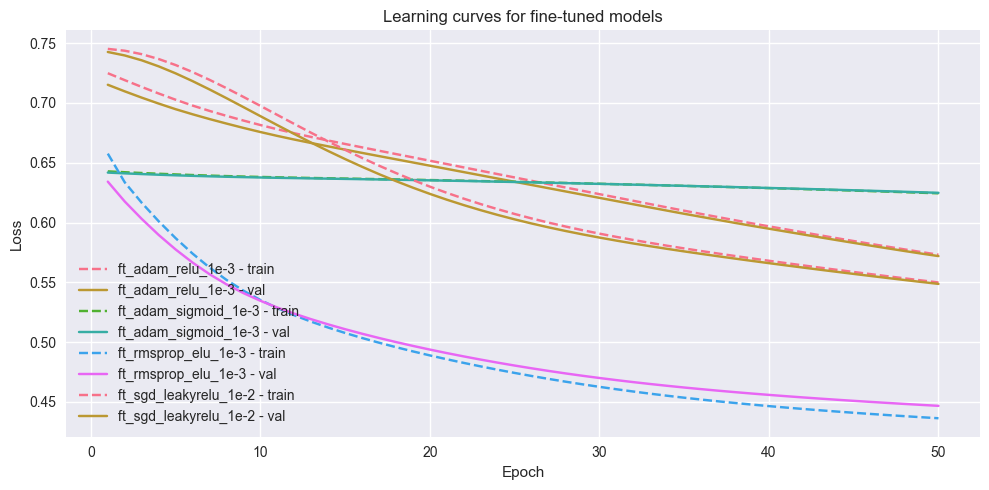

In [12]:
"""Plot learning curves (train/val loss) for each fine-tuned model."""

plt.figure(figsize=(10, 5))

for name, group in learning_curves_df.groupby("config_name"):
    plt.plot(group["epoch"], group["train_loss"], linestyle="--", label=f"{name} - train")
    plt.plot(group["epoch"], group["val_loss"], label=f"{name} - val")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning curves for fine-tuned models")
plt.legend()
plt.tight_layout()
plt.show()
